# Healthcare Analytics for Doctor Visits

### VOIS × AICTE TIRTC DIY Project

## Project Objective

This project analyzes healthcare-related data to identify patterns and associations associated with the number of doctor visits.

The analysis examines demographic, health, financial, and chronic-condition variables to understand how they relate to doctor visits.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [31]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

The dataset contains information about individuals, their health conditions, healthcare support, and the number of doctor visits.

In [32]:
from google.colab import files

uploaded = files.upload()

Saving 1776250375-P2-Healthcare Analytics for Doctor Visits.csv to 1776250375-P2-Healthcare Analytics for Doctor Visits.csv


In [33]:
# Get uploaded filename
file_name = list(uploaded.keys())[0]

# Load dataset
original_df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)

Dataset loaded successfully!
File: 1776250375-P2-Healthcare Analytics for Doctor Visits.csv


> **Note:** Upload the provided project CSV file when prompted by Google Colab.

## 2. Dataset Understanding

Before performing analysis, the dataset is examined to understand its size, structure, data types, and variables.

In [34]:
# Display first 5 records

original_df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.190,0.550,1,4,1,yes,no,no,no,no
1,2,1,female,0.190,0.450,1,2,1,yes,no,no,no,no
2,3,1,male,0.190,0.900,3,0,0,no,no,no,no,no
3,4,1,male,0.190,0.150,1,0,0,no,no,no,no,no
4,5,1,male,0.190,0.450,2,5,1,no,no,no,yes,no


In [35]:
# Dataset dimensions

rows, columns = original_df.shape

print("Number of records:", rows)
print("Number of columns:", columns)

Number of records: 5190
Number of columns: 13


In [36]:
# Dataset information

original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [37]:
# Statistical summary of numerical variables

original_df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000,5190.000,5190.000,5190.000,5190.000,5190.000,5190.000
mean,2595.500,0.302,0.406,0.583,1.432,0.862,1.218
std,1498.368,0.798,0.205,0.369,1.384,2.888,2.124
min,1.000,0.000,0.190,0.000,0.000,0.000,0.000
25%,1298.250,0.000,0.220,0.250,0.000,0.000,0.000
50%,2595.500,0.000,0.320,0.550,1.000,0.000,0.000
75%,3892.750,0.000,0.620,0.900,2.000,0.000,2.000
max,5190.000,9.000,0.720,1.500,5.000,14.000,12.000


## 3. Data Preprocessing

The dataset is checked for missing values and duplicate records.

The `Unnamed: 0` column is a record identifier and is not used for healthcare analysis.

In [38]:
# Check missing values

missing_values = original_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", original_df.isnull().sum().sum())

Missing values in each column:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

Total missing values: 0


In [39]:
# Check uniqueness of record IDs

print("Total records:", len(original_df))
print("Unique record IDs:", original_df["Unnamed: 0"].nunique())
print(
    "Duplicate record IDs:",
    original_df["Unnamed: 0"].duplicated().sum()
)

Total records: 5190
Unique record IDs: 5190
Duplicate record IDs: 0


In [40]:
# Remove record identifier from analytical dataset

df = original_df.drop(columns=["Unnamed: 0"]).copy()

print("Analytical dataset shape:", df.shape)

Analytical dataset shape: (5190, 12)


In [41]:
# Check identical analytical rows

identical_rows = df.duplicated().sum()

print("Identical rows excluding record ID:", identical_rows)

print("\nDecision:")
print("No records were removed as duplicates.")
print(
    "Reason: the original dataset contains a unique record ID for every observation."
)

Identical rows excluding record ID: 1320

Decision:
No records were removed as duplicates.
Reason: the original dataset contains a unique record ID for every observation.


In [42]:
# Final data quality check

print("FINAL DATA QUALITY CHECK")
print("=" * 45)

print("Total records:", len(original_df))
print("Unique record IDs:", original_df["Unnamed: 0"].nunique())
print("Missing values:", df.isnull().sum().sum())
print("Identical analytical rows:", df.duplicated().sum())
print(
    "Duplicate record IDs:",
    original_df["Unnamed: 0"].duplicated().sum()
)

print("\nDecision: No observations removed.")

FINAL DATA QUALITY CHECK
Total records: 5190
Unique record IDs: 5190
Missing values: 0
Identical analytical rows: 1320
Duplicate record IDs: 0

Decision: No observations removed.


## Data Preprocessing Summary

The dataset initially contained 5,190 records and 13 columns.

The `Unnamed: 0` column was identified as a record identifier and was excluded from analytical calculations.

No missing values were found in the dataset.

The original dataset contains 5,190 unique record IDs. Although some rows have identical values across the analytical variables after excluding the record identifier, these observations were retained because they correspond to distinct records.

Therefore, no observations were removed during duplicate handling.

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of doctor visits and examine relationships between demographic, health, financial, and healthcare-related variables.

The analysis is divided into:

1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis

## 4. Univariate Analysis

Univariate analysis is used to study the distribution of individual variables.

The following three variables are analyzed:

- Gender
- Age
- Doctor Visits

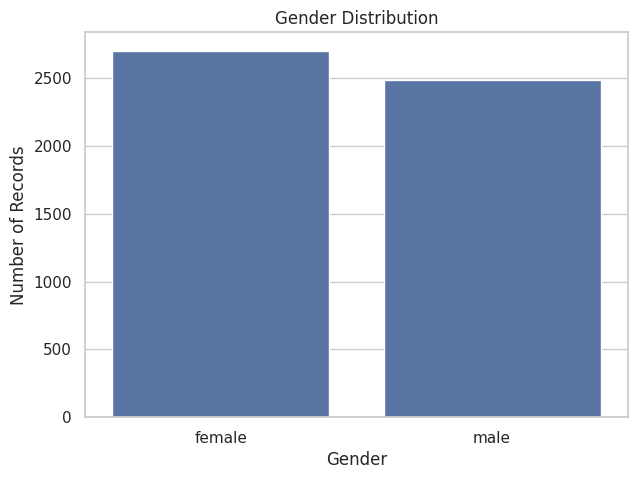

In [13]:
# Univariate Graph 1: Gender Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Records")

plt.show()

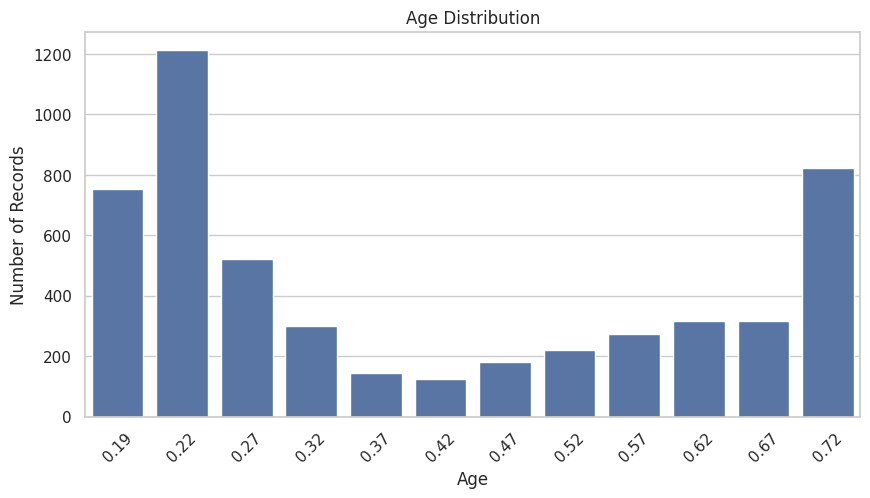

In [14]:
# Univariate Graph 2: Age Distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="age"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

### Note on Age Representation

The `age` variable is stored in the dataset using decimal values rather than conventional whole-number ages. Therefore, the analysis uses the original numerical age values without creating artificial age groups.

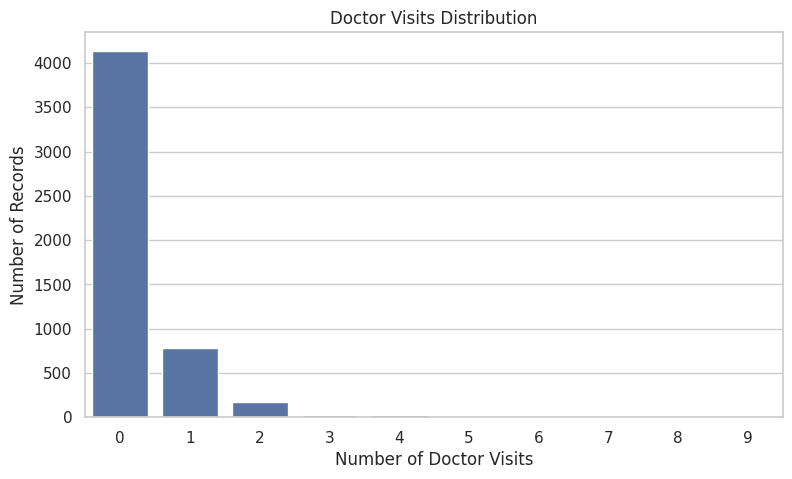

In [15]:
# Univariate Graph 3: Doctor Visits Distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="visits"
)

plt.title("Doctor Visits Distribution")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of Records")

plt.show()

## 5. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

The analysis focuses on gender, illness score, health condition, reduced activity, and doctor visits.

In [16]:
# Gender Analysis

gender_analysis = df.groupby("gender")["visits"].agg(
    ["count", "mean", "median"]
)

gender_analysis

,count,mean,median
gender,,,
female,2702,0.362,0.000
male,2488,0.236,0.000


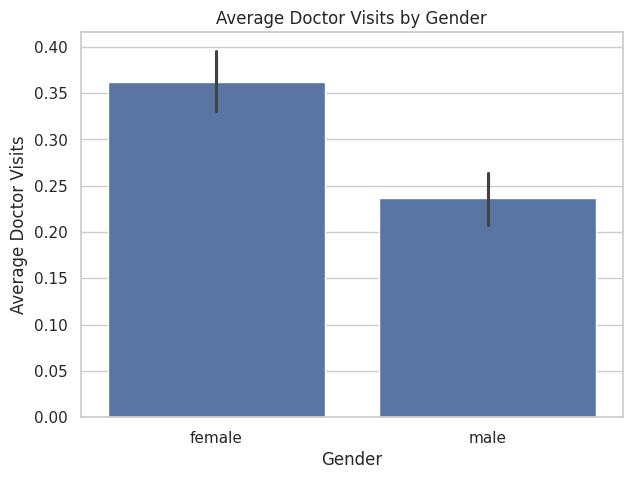

In [17]:
# Bivariate Graph 1: Average Doctor Visits by Gender

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="gender",
    y="visits",
    estimator="mean"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")

plt.show()

In [18]:
# Illness Score Analysis

illness_analysis = df.groupby("illness")["visits"].agg(
    ["count", "mean", "median"]
)

illness_analysis

,count,mean,median
illness,,,
0,1554,0.079,0.000
1,1638,0.295,0.000
2,946,0.404,0.000
3,542,0.421,0.000
4,274,0.577,0.000
5,236,0.814,0.000


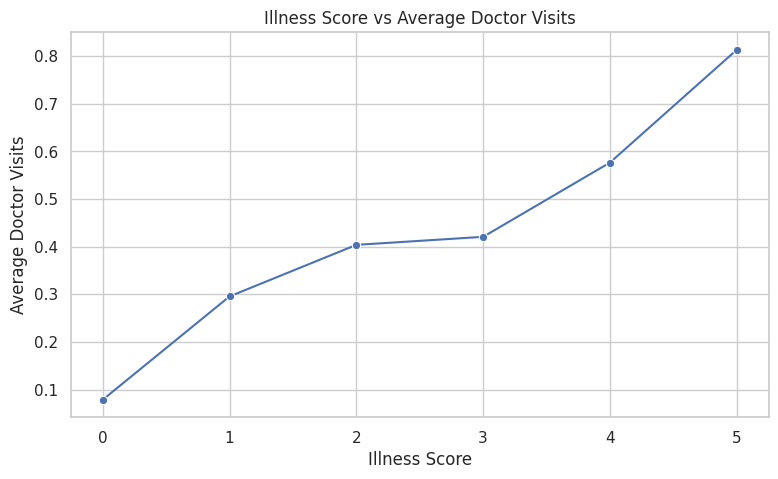

In [19]:
# Bivariate Graph 2: Illness Score vs Average Doctor Visits

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=illness_analysis,
    x=illness_analysis.index,
    y="mean",
    marker="o"
)

plt.title("Illness Score vs Average Doctor Visits")
plt.xlabel("Illness Score")
plt.ylabel("Average Doctor Visits")

plt.grid(True)

plt.show()

In [20]:
# Bivariate Graph 3: Health vs Average Doctor Visits

health_analysis = df.groupby("health")["visits"].agg(
    ["count", "mean", "median"]
)

health_analysis

,count,mean,median
health,,,
0,3026,0.199,0.000
1,823,0.335,0.000
2,446,0.381,0.000
3,273,0.418,0.000
4,187,0.535,0.000
5,132,0.530,0.000
6,104,0.625,0.000
7,61,0.918,0.000
8,42,0.476,0.000


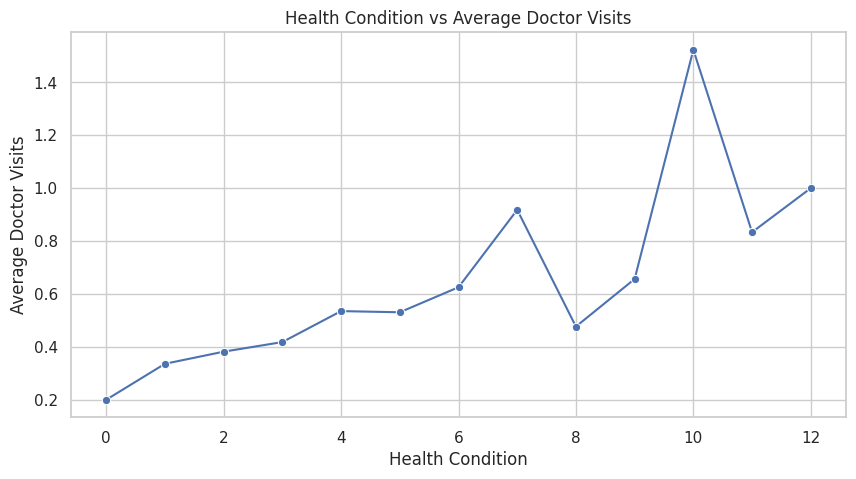

In [21]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=health_analysis,
    x=health_analysis.index,
    y="mean",
    marker="o"
)

plt.title("Health Condition vs Average Doctor Visits")
plt.xlabel("Health Condition")
plt.ylabel("Average Doctor Visits")

plt.grid(True)

plt.show()

In [22]:
# Bivariate Graph 4: Reduced Activity vs Average Doctor Visits

reduced_analysis = df.groupby("reduced")["visits"].agg(
    ["count", "mean", "median"]
)

reduced_analysis

,count,mean,median
reduced,,,
0,4454,0.184,0.000
1,177,0.356,0.000
2,108,0.574,0.000
3,74,1.095,1.000
4,45,0.800,1.000
5,40,1.275,1.000
6,17,1.176,1.000
7,38,1.184,1.000
8,17,1.176,1.000


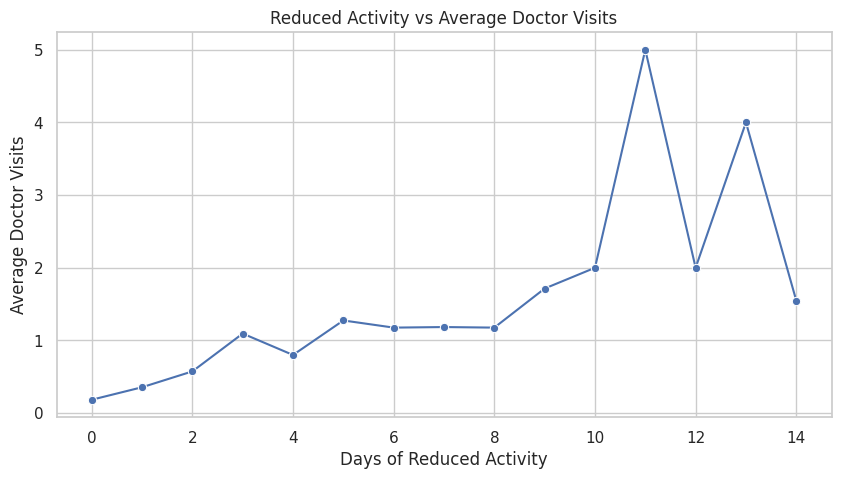

In [23]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=reduced_analysis,
    x=reduced_analysis.index,
    y="mean",
    marker="o"
)

plt.title("Reduced Activity vs Average Doctor Visits")
plt.xlabel("Days of Reduced Activity")
plt.ylabel("Average Doctor Visits")

plt.grid(True)

plt.show()

In [24]:
# Bivariate Graph 5: Long-Term Chronic Condition vs Average Doctor Visits

chronic_analysis = df.groupby("lchronic")["visits"].agg(
    ["count", "mean", "median"]
)

chronic_analysis

,count,mean,median
lchronic,,,
no,4585,0.262,0.000
yes,605,0.603,0.000


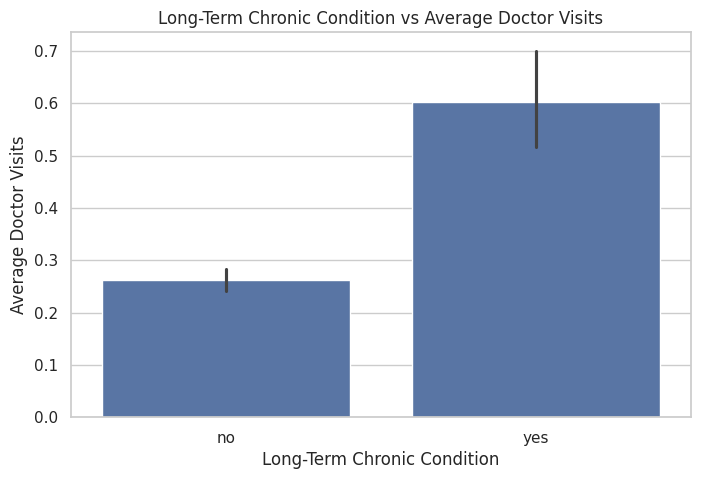

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="lchronic",
    y="visits",
    estimator="mean"
)

plt.title("Long-Term Chronic Condition vs Average Doctor Visits")
plt.xlabel("Long-Term Chronic Condition")
plt.ylabel("Average Doctor Visits")

plt.show()

## 6. Multivariate Analysis

Multivariate analysis examines multiple variables together to identify relationships and patterns in the healthcare dataset.

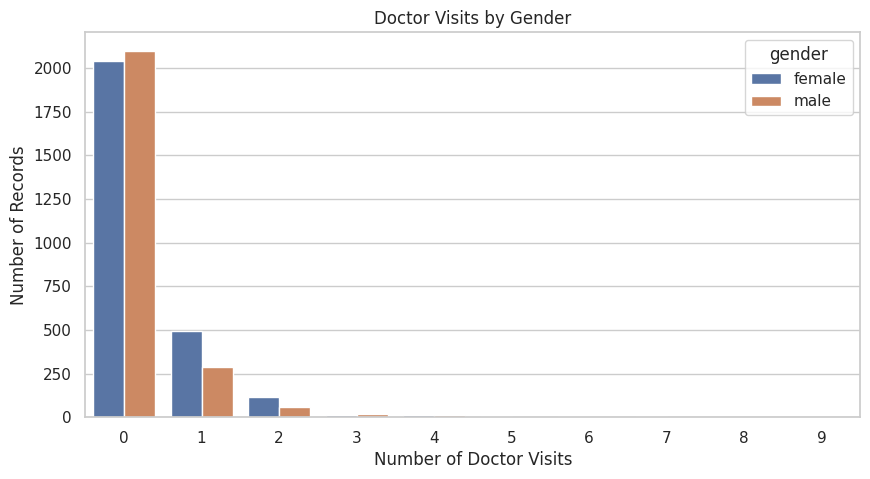

In [26]:
# Multivariate Graph 1: Doctor Visits by Gender

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="visits",
    hue="gender"
)

plt.title("Doctor Visits by Gender")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of Records")

plt.show()

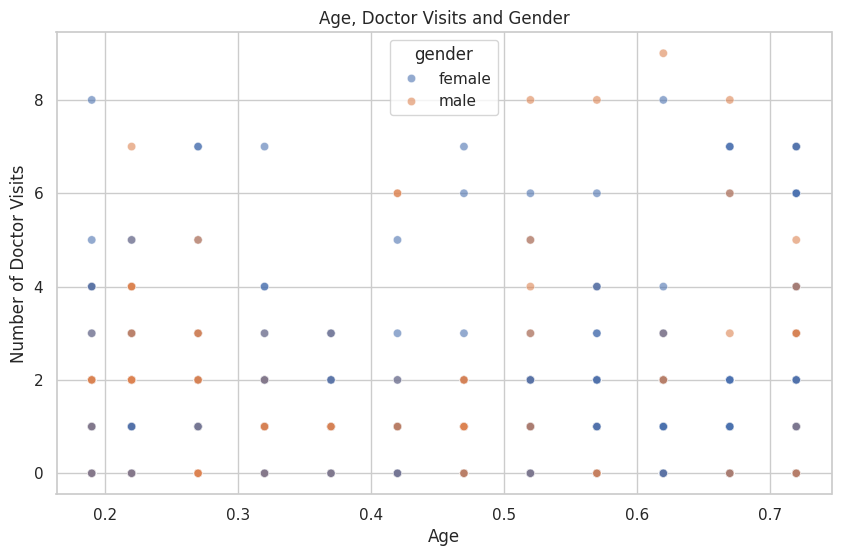

In [27]:
# Multivariate Graph 2: Age, Doctor Visits and Gender

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="visits",
    hue="gender",
    alpha=0.6
)

plt.title("Age, Doctor Visits and Gender")
plt.xlabel("Age")
plt.ylabel("Number of Doctor Visits")

plt.show()

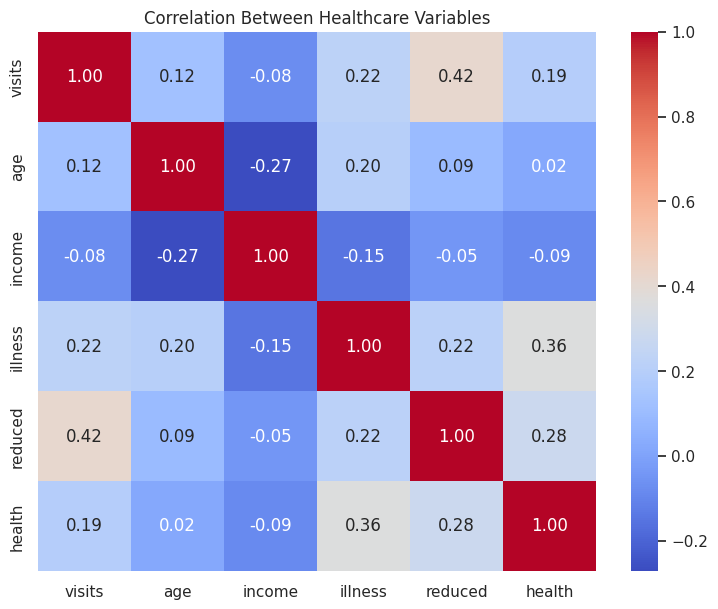

In [28]:
# Multivariate Graph 3: Correlation Heatmap

numeric_columns = [
    "visits",
    "age",
    "income",
    "illness",
    "reduced",
    "health"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Healthcare Variables")

plt.show()

## Key Insights

- The dataset contains 5,190 records, with no missing values and no duplicate record IDs.
- The average number of doctor visits is 0.302, while the median is 0.
- Female participants have a higher average number of doctor visits (0.362) than male participants (0.236).
- Average doctor visits generally increase as the illness score increases, from 0.079 visits for illness score 0 to 0.814 visits for illness score 5.
- Participants with a long-term chronic condition have a higher average number of doctor visits (0.603) than those without one (0.262).
- Reduced activity has the strongest correlation with doctor visits among the numerical variables, with a correlation of 0.419.
- Illness score and health condition also show positive correlations with doctor visits, with correlation values of 0.224 and 0.193 respectively.
- Age has a weaker positive correlation with doctor visits (0.125), while income has a weak negative correlation (-0.077).
- The analysis shows that health-related factors have stronger relationships with doctor visits than income or age in this dataset.

### Interpretation Note

The findings in this project describe associations and patterns observed in the dataset. They do not establish that one variable directly causes changes in doctor visits.

In [29]:
# Generate key statistical results

print("KEY STATISTICS")
print("=" * 50)

print(
    "Average doctor visits:",
    round(df["visits"].mean(), 3)
)

print(
    "Median doctor visits:",
    df["visits"].median()
)

print(
    "Maximum doctor visits:",
    df["visits"].max()
)

print(
    "\nAverage visits by gender:"
)

print(
    df.groupby("gender")["visits"]
    .mean()
    .round(3)
)

print(
    "\nAverage visits by illness score:"
)

print(
    df.groupby("illness")["visits"]
    .mean()
    .round(3)
)

print(
    "\nAverage visits by long-term chronic condition:"
)

print(
    df.groupby("lchronic")["visits"]
    .mean()
    .round(3)
)

KEY STATISTICS
Average doctor visits: 0.302
Median doctor visits: 0.0
Maximum doctor visits: 9

Average visits by gender:
gender
female   0.362
male     0.236
Name: visits, dtype: float64

Average visits by illness score:
illness
0   0.079
1   0.295
2   0.404
3   0.421
4   0.577
5   0.814
Name: visits, dtype: float64

Average visits by long-term chronic condition:
lchronic
no    0.262
yes   0.603
Name: visits, dtype: float64


In [30]:
# Correlation of numerical variables with doctor visits

visit_correlations = (
    df[
        ["age", "income", "illness", "reduced", "health", "visits"]
    ]
    .corr()["visits"]
    .sort_values(ascending=False)
)

visit_correlations

,visits
visits,1.000
reduced,0.419
illness,0.224
health,0.193
age,0.125
income,-0.077


## Conclusion

This project analyzed 5,190 records to identify patterns associated with doctor visits.

The analysis found that doctor visits are related to several health-related factors. Average doctor visits generally increased with illness score, and participants with long-term chronic conditions had higher average doctor visits than those without such conditions. Reduced activity showed the strongest positive correlation with doctor visits among the numerical variables analyzed.

Gender also showed a difference in average doctor visits, with female participants having a higher average than male participants. Age showed a weak positive relationship with doctor visits, while income showed a weak negative relationship.

Overall, this project demonstrates how data analytics and visualization can be used to identify patterns and associations in healthcare-related data and support a better understanding of factors related to doctor visits.

## Project Summary

### Dataset
5,190 healthcare-related records and 13 original columns.

### Analysis Performed
- Data cleaning and quality checking
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Correlation analysis
- Healthcare-related pattern identification

### Main Finding
Health-related variables, particularly reduced activity, illness score, and chronic condition status, show noticeable relationships with doctor visits in the dataset.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab